# Powerlifting EDA 

Target: BestDeadliftKg

understand the data, clean it properly

## 1. Imports and Load

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv('openpowerlifting.csv', low_memory=False)
print("Shape:", df.shape)
df.head()

Shape: (386414, 17)


,MeetID,Name,Sex,Equipment,Age,Division,BodyweightKg,WeightClassKg,Squat4Kg,BestSquatKg,Bench4Kg,BestBenchKg,Deadlift4Kg,BestDeadliftKg,TotalKg,Place,Wilks
0,0,Angie Belk Terry,F,Wraps,47.0,Mst 45-49,59.60,60,NaN,47.63,NaN,20.41,NaN,70.31,138.35,1,155.05
1,0,Dawn Bogart,F,Single-ply,42.0,Mst 40-44,58.51,60,NaN,142.88,NaN,95.25,NaN,163.29,401.42,1,456.38
2,0,Dawn Bogart,F,Single-ply,42.0,Open Senior,58.51,60,NaN,142.88,NaN,95.25,NaN,163.29,401.42,1,456.38
3,0,Dawn Bogart,F,Raw,42.0,Open Senior,58.51,60,NaN,NaN,NaN,95.25,NaN,NaN,95.25,1,108.29
4,0,Destiny Dula,F,Raw,18.0,Teen 18-19,63.68,67.5,NaN,NaN,NaN,31.75,NaN,90.72,122.47,1,130.47


## 2. First Look

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 386414 entries, 0 to 386413
Data columns (total 17 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   MeetID          386414 non-null  int64  
 1   Name            386414 non-null  str    
 2   Sex             386414 non-null  str    
 3   Equipment       386414 non-null  str    
 4   Age             147147 non-null  float64
 5   Division        370571 non-null  str    
 6   BodyweightKg    384012 non-null  float64
 7   WeightClassKg   382602 non-null  str    
 8   Squat4Kg        1243 non-null    float64
 9   BestSquatKg     298071 non-null  float64
 10  Bench4Kg        1962 non-null    float64
 11  BestBenchKg     356364 non-null  float64
 12  Deadlift4Kg     2800 non-null    float64
 13  BestDeadliftKg  317847 non-null  float64
 14  TotalKg         363237 non-null  float64
 15  Place           385322 non-null  str    
 16  Wilks           362194 non-null  float64
dtypes: float64(10), int64

In [4]:
missing = (df.isnull().mean() * 100).round(2).sort_values(ascending=False)
missing

Squat4Kg          99.68
Bench4Kg          99.49
Deadlift4Kg       99.28
Age               61.92
BestSquatKg       22.86
BestDeadliftKg    17.74
BestBenchKg        7.78
Wilks              6.27
TotalKg            6.00
Division           4.10
WeightClassKg      0.99
BodyweightKg       0.62
Place              0.28
MeetID             0.00
Sex                0.00
Equipment          0.00
Name               0.00
dtype: float64

In [5]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 545


**Observation:** 545 exact duplicate rows exist and several columns are mostly missing (`Squat4Kg`, `Bench4Kg`, `Deadlift4Kg` are 4th-attempt columns, over 99% empty). Handling both before doing any analysis.

In [6]:
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (385869, 17)


## 3. Target Variable

Target: **`BestDeadliftKg`** — a continuous number, so this is a regression target.

In [7]:
df = df[df['BestDeadliftKg'].notna()]
print("Rows with a deadlift result:", df.shape[0])
df['BestDeadliftKg'].describe()

Rows with a deadlift result: 317447


count    317447.000000
mean        195.038527
std          61.567345
min        -410.000000
25%         147.500000
50%         195.000000
75%         238.140000
max         460.400000
Name: BestDeadliftKg, dtype: float64

## 4. Column-by-Column: Keep or Drop

Checking every column for: ID columns, data leakage, messy/unusable categories, and
duplicate information — same standard I'd apply to any dataset before modeling.

**Leakage check first**, since the target changed from `TotalKg` to `BestDeadliftKg`, the
leakage risk changes too — `TotalKg` is now a near-perfect giveaway of the target.

In [8]:
# TotalKg = BestSquatKg + BestBenchKg + BestDeadliftKg -- if true, TotalKg leaks the target
check = df.dropna(subset=['BestSquatKg','BestBenchKg','BestDeadliftKg','TotalKg'])
match = ((check['BestSquatKg'] + check['BestBenchKg'] + check['BestDeadliftKg']).round(1)
         == check['TotalKg'].round(1))
print("TotalKg = Squat+Bench+Deadlift match rate:", round(match.mean()*100, 2), "%")

print("Wilks correlation with TotalKg:", round(df['Wilks'].corr(df['TotalKg']), 3))

TotalKg = Squat+Bench+Deadlift match rate: 98.44 %
Wilks correlation with TotalKg: 0.818


**Observation:** 98%+ match confirms `TotalKg` is just `Squat+Bench+Deadlift` added up —
dropping it. `Wilks` is 0.82 correlated with `TotalKg` (it's calculated from Total and
bodyweight), so it leaks too — dropping it as well.

### Column table

| Column | Keep/Drop | Reason |
|---|---|---|
| MeetID | Drop | Identifier, no predictive meaning |
| Name | **Keep** | Not used as a raw model input, but useful for athlete-level analysis below (and a future "lifter history" feature) |
| Sex | **Keep** | Affects strength |
| Equipment | **Keep** | Affects how much can be lifted |
| Age | **Keep** | 61% missing in this subset, but genuinely relevant — leaving as NaN for the modeling pipeline to impute properly, rather than throwing away most of the data |
| Division | Drop | Thousands of inconsistent, federation-specific text values |
| BodyweightKg | **Keep** | Affects lift capacity |
| WeightClassKg | **Keep** | Cleaning to a plain number below |
| Squat4Kg / Bench4Kg / Deadlift4Kg | Drop | 99%+ missing (4th/record attempt, not a normal lift) |
| BestSquatKg / BestBenchKg | **Keep** | In a real meet, squat and bench happen *before* deadlift, so these are legitimately known at prediction time — not leakage, just earlier information from the same competition |
| TotalKg | Drop | Leakage — proven above |
| Place | Drop | Only decided after everyone has lifted |
| Wilks | Drop | Leakage — derived from TotalKg |
| BestDeadliftKg | Target | — |

In [9]:
df = df.drop(columns=['MeetID','Division','Squat4Kg','Bench4Kg','Deadlift4Kg','TotalKg','Place','Wilks'])
print("Remaining columns:", list(df.columns))
print("Shape:", df.shape)

Remaining columns: ['Name', 'Sex', 'Equipment', 'Age', 'BodyweightKg', 'WeightClassKg', 'BestSquatKg', 'BestBenchKg', 'BestDeadliftKg']
Shape: (317447, 9)


## 5. Cleaning Values

`WeightClassKg` is text like `120+` — converting to a plain number.

In [10]:
df['WeightClassKg'] = df['WeightClassKg'].str.replace('+', '', regex=False)
df['WeightClassKg'] = pd.to_numeric(df['WeightClassKg'], errors='coerce')
df[['WeightClassKg']].describe()

,WeightClassKg
count,315319.000000
mean,87.476663
std,21.579567
min,30.000000
25%,72.000000
50%,84.000000
75%,100.000000
max,155.000000


### Invalid lift values

A negative value in `BestSquatKg`/`BestBenchKg`/`BestDeadliftKg` means the lifter **failed**
that lift, not that it's a real "best" result. Checking before deciding what to do about it.

In [11]:
for c in ['BestSquatKg','BestBenchKg','BestDeadliftKg']:
    print(c, "-> negative values:", (df[c] < 0).sum(), "| min value:", df[c].min())

BestSquatKg -> negative values: 451 | min value: -445.0
BestBenchKg -> negative values: 527 | min value: -362.5
BestDeadliftKg -> negative values: 509 | min value: -410.0


**Observation:** hundreds of negative values in each lift column, down to around -400kg — these are failed attempts recorded as negative numbers, not valid results. Keeping them would teach the model that a "failed lift" is a real, very low score. Dropping rows where any of the three lifts is not a positive number.

In [12]:
before = df.shape[0]
df = df[(df['BestSquatKg'] > 0) & (df['BestBenchKg'] > 0) & (df['BestDeadliftKg'] > 0)]
print("Rows before:", before, "| after:", df.shape[0], "| removed:", before - df.shape[0])

Rows before: 317447 | after: 286491 | removed: 30956


## 6. Univariate Analysis

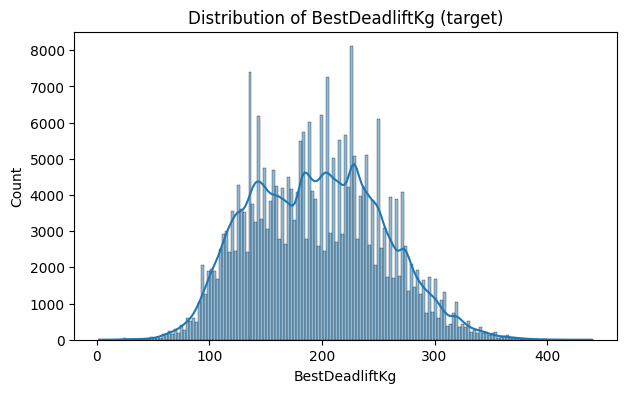

In [13]:
plt.figure(figsize=(7,4))
sns.histplot(df['BestDeadliftKg'], kde=True)
plt.title('Distribution of BestDeadliftKg (target)')
plt.show()

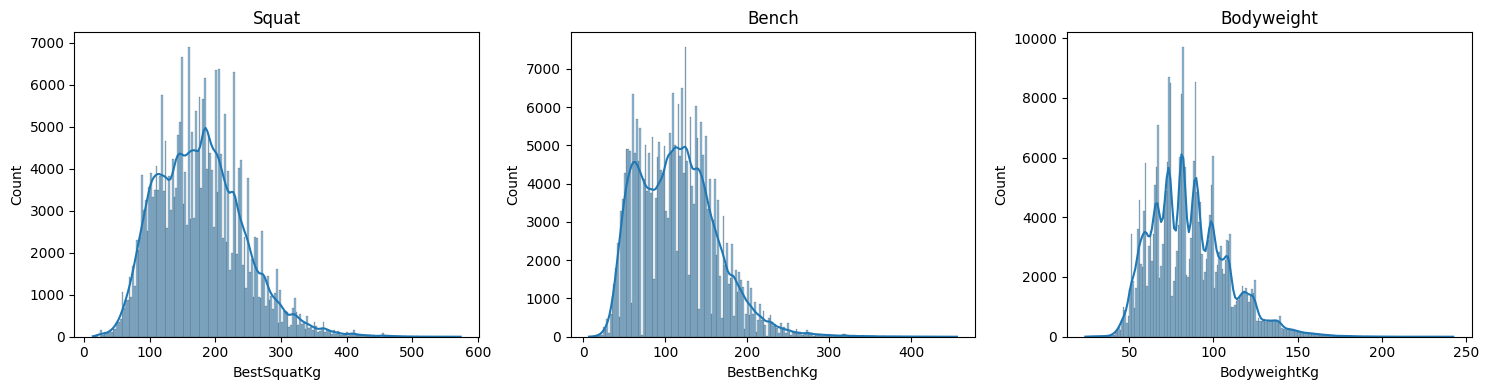

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
sns.histplot(df['BestSquatKg'], kde=True, ax=axes[0]).set_title('Squat')
sns.histplot(df['BestBenchKg'], kde=True, ax=axes[1]).set_title('Bench')
sns.histplot(df['BodyweightKg'], kde=True, ax=axes[2]).set_title('Bodyweight')
plt.tight_layout()
plt.show()

**Observation:** all three are right-skewed (a long tail of very strong lifters), which is expected for physical performance data — most people cluster in a normal range with a few outliers at the top, not data errors.

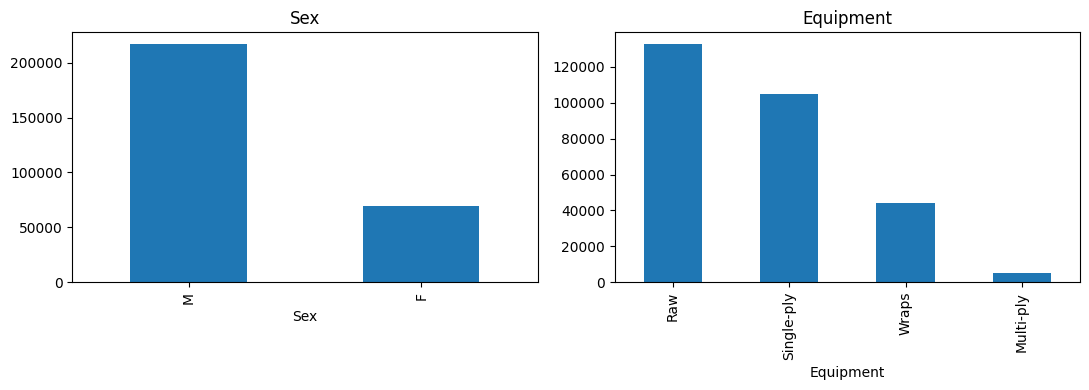

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11,4))
df['Sex'].value_counts().plot(kind='bar', ax=axes[0], title='Sex')
df['Equipment'].value_counts().plot(kind='bar', ax=axes[1], title='Equipment')
plt.tight_layout()
plt.show()

**Observation:** the dataset is majority male, and majority `Raw` equipment — worth remembering when interpreting any average later, since it's not a balanced sample across groups.

## 7. Bivariate Analysis — Each Feature vs Deadlift

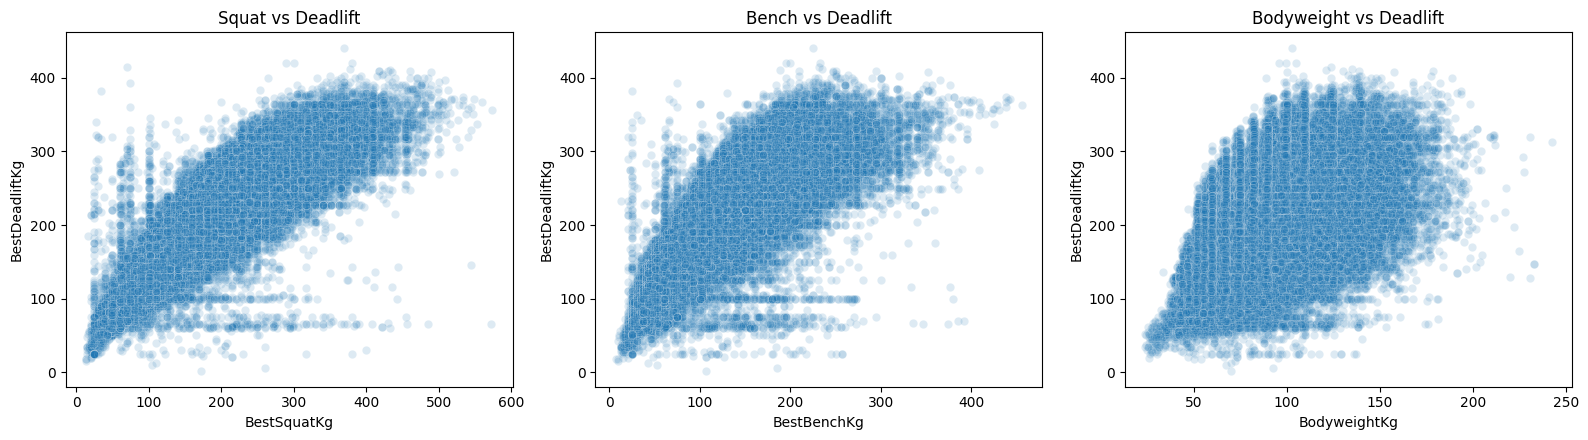

BestSquatKg       0.892348
BestBenchKg       0.861161
BodyweightKg      0.599536
BestDeadliftKg    1.000000
Name: BestDeadliftKg, dtype: float64


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16,4.5))
sns.scatterplot(x='BestSquatKg', y='BestDeadliftKg', data=df, alpha=0.15, ax=axes[0])
sns.scatterplot(x='BestBenchKg', y='BestDeadliftKg', data=df, alpha=0.15, ax=axes[1])
sns.scatterplot(x='BodyweightKg', y='BestDeadliftKg', data=df, alpha=0.15, ax=axes[2])
axes[0].set_title('Squat vs Deadlift'); axes[1].set_title('Bench vs Deadlift'); axes[2].set_title('Bodyweight vs Deadlift')
plt.tight_layout()
plt.show()

print(df[['BestSquatKg','BestBenchKg','BodyweightKg','BestDeadliftKg']].corr()['BestDeadliftKg'])

**Observation:** Squat has the strongest relationship with Deadlift (makes sense — both are lower-body/posterior-chain lifts), Bench is weaker (a different muscle group), and Bodyweight has the weakest of the three but still a clear positive trend.

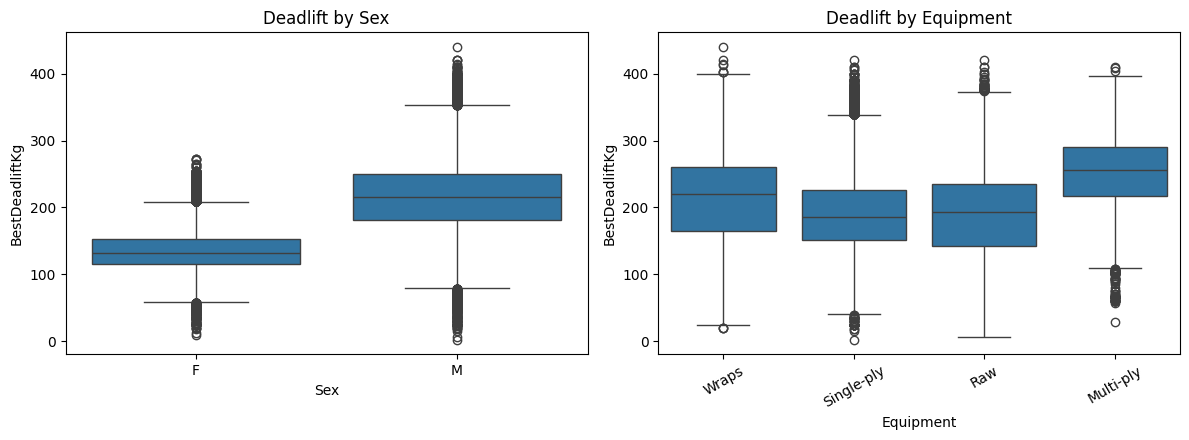

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12,4.5))
sns.boxplot(x='Sex', y='BestDeadliftKg', data=df, ax=axes[0])
sns.boxplot(x='Equipment', y='BestDeadliftKg', data=df, ax=axes[1])
axes[1].tick_params(axis='x', rotation=30)
axes[0].set_title('Deadlift by Sex'); axes[1].set_title('Deadlift by Equipment')
plt.tight_layout()
plt.show()

**Observation:** a clear gap between Sex categories, as expected. Equipment shows some separation too, though less than expected — likely because supportive gear helps squat and bench more directly than deadlift.

## 8. Multivariate Analysis

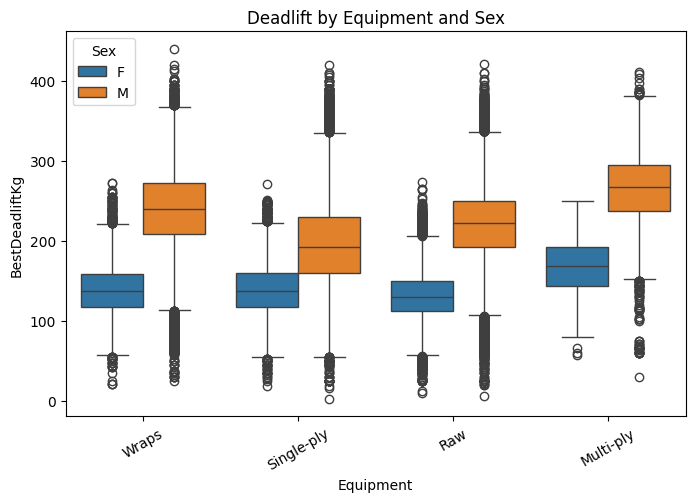

In [18]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Equipment', y='BestDeadliftKg', hue='Sex', data=df)
plt.xticks(rotation=30)
plt.title('Deadlift by Equipment and Sex')
plt.show()

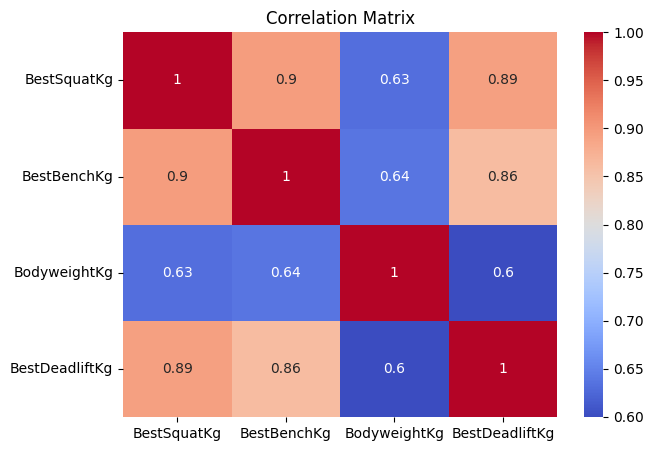

In [19]:
plt.figure(figsize=(7,5))
sns.heatmap(df[['BestSquatKg','BestBenchKg','BodyweightKg','BestDeadliftKg']].corr(),
            annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

**Observation:** Sex and Equipment interact — the male/female gap and the equipment-tier gap both hold up within each other's groups, meaning both carry independent information rather than one explaining the other away.

## 9. Athlete-Level Analysis

Powerlifters compete in multiple meets, so `Name` lets me look at performance across meets,
not just at a single-row level.

In [20]:
top10 = (df[['Name','Sex','Equipment','BestDeadliftKg']]
         .sort_values('BestDeadliftKg', ascending=False).head(10))
top10

,Name,Sex,Equipment,BestDeadliftKg
385153,Yury Belkin,M,Wraps,440.00
384208,Cailer Woolam,M,Raw,420.50
384209,Yury Belkin,M,Wraps,420.00
63641,Krzysztof Wierzbicki,M,Single-ply,420.00
170999,Aria Attia,M,Wraps,415.04
384199,Steve Johnson,M,Wraps,412.50
169068,Tory Pelzer,M,Multi-ply,410.50
235802,Eric Lilliebridge,M,Raw,410.00
154944,Andrey Malanichev,M,Single-ply,410.00
151560,Josh Morris,M,Raw,410.00


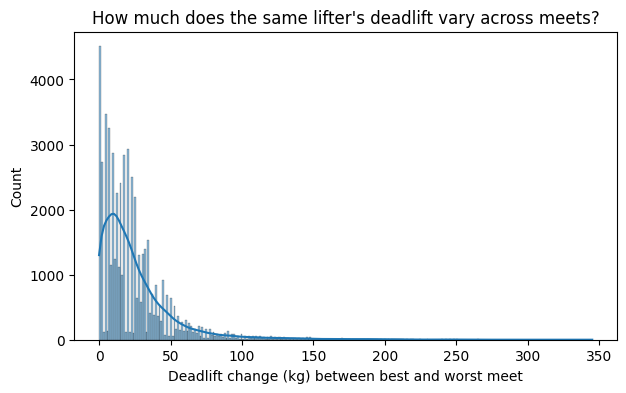

Median change: 18.0 kg | Lifters with 2+ meets: 56391


In [21]:
appearance_count = df['Name'].value_counts()
repeat_lifters = appearance_count[appearance_count > 1].index
df_repeat = df[df['Name'].isin(repeat_lifters)]

change = df_repeat.groupby('Name')['BestDeadliftKg'].agg(lambda x: x.max() - x.min())

plt.figure(figsize=(7,4))
sns.histplot(change, kde=True)
plt.xlabel('Deadlift change (kg) between best and worst meet')
plt.title('How much does the same lifter\'s deadlift vary across meets?')
plt.show()

print("Median change:", round(change.median(),1), "kg | Lifters with 2+ meets:", len(repeat_lifters))

**Observation:** the same lifter's deadlift varies by a noticeable amount meet to meet — real day-to-day performance is not fixed, which is useful context: even a perfect model can't predict a specific day's number exactly, because the person themselves doesn't perform identically every time.

## 10. Final Missing-Value Check

In [22]:
(df.isnull().mean() * 100).round(2).sort_values(ascending=False)

Age               62.73
WeightClassKg      0.63
BodyweightKg       0.21
Name               0.00
Equipment          0.00
Sex                0.00
BestSquatKg        0.00
BestBenchKg        0.00
BestDeadliftKg     0.00
dtype: float64

**Decision:** `Age` still has missing values (~61%) — not dropping those rows, since that
would throw away most of the dataset for one feature. Leaving `Age` as-is (with NaN) so a
modeling pipeline can impute it properly using only its own training data, which avoids
leaking information between train and test sets. All other columns are complete or near-complete after the cleaning above.

## 11. Save Clean CSV

In [23]:
print("Final shape:", df.shape)
print("Final columns:", list(df.columns))
df.head()

Final shape: (286491, 9)
Final columns: ['Name', 'Sex', 'Equipment', 'Age', 'BodyweightKg', 'WeightClassKg', 'BestSquatKg', 'BestBenchKg', 'BestDeadliftKg']


,Name,Sex,Equipment,Age,BodyweightKg,WeightClassKg,BestSquatKg,BestBenchKg,BestDeadliftKg
0,Angie Belk Terry,F,Wraps,47.0,59.60,60.0,47.63,20.41,70.31
1,Dawn Bogart,F,Single-ply,42.0,58.51,60.0,142.88,95.25,163.29
2,Dawn Bogart,F,Single-ply,42.0,58.51,60.0,142.88,95.25,163.29
5,Courtney Norris,F,Wraps,28.0,62.41,67.5,170.10,77.11,145.15
6,Maureen Clary,F,Raw,60.0,67.31,67.5,124.74,95.25,163.29


In [24]:
df.to_csv('openpowerlifting_cleaned.csv', index=False)
print("Saved: openpowerlifting_cleaned.csv")

Saved: openpowerlifting_cleaned.csv


## 12. Insights

- **Squat is the strongest predictor of Deadlift** among the numeric features (highest
  correlation), followed by Bench, then Bodyweight.
- **`TotalKg` and `Wilks` both leak the target** and must not be used as model inputs —
  proven directly in Section 4, not assumed.
- **Negative lift values are failed attempts**, not valid results or data errors — removing
  them (Section 5) is necessary before any distribution or correlation looks meaningful.
- **Sex and Equipment both matter independently** — the gap between groups holds up even
  after controlling for the other.
- **The same lifter's deadlift varies meaningfully between meets** — a reminder that no
  model will hit R²=1.0 on this kind of human performance data, since even the same person
  doesn't repeat their result exactly.
- **`Age` is kept despite 61% missingness** rather than dropped outright — it's genuinely
  relevant and better handled with proper imputation at modeling time than discarded here.